# Restaurant Tipping Behavior and Payment Patterns

This notebook explores tipping behavior using the Seaborn `tips` dataset.
The analysis began with a simple question about the relationship between total bill and tip,
but expanded into a broader behavioral interpretation of payment patterns.

## 1. Introduction / Motivation

This project began by asking whether a higher total bill leads to a higher tip.
As the analysis progressed, I became more interested in the behavioral meaning behind the variables,
especially whether the variable `sex` could be interpreted as the sex of the bill payer rather than all diners at the table.

Main questions explored:
- Is there a linear relationship between `total_bill` and `tip`?
- Do tipping patterns differ by sex, day, time, smoking status, and party size?
- Can the dataset suggest broader payment behavior patterns, especially during dinner?

## 2. Dataset

The Seaborn `tips` dataset contains restaurant payment records.
Main variables:
- `total_bill`
- `tip`
- `sex`
- `smoker`
- `day`
- `time`
- `size`

In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df.head()



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


The dataset contains 244 observations and 7 variables.
At this stage, I inspected the structure of the data before beginning the analysis.

## 3. Exploratory Analysis

### 3.1 Relationship between Total Bill and Tip

The first step was to examine whether tip amount increases as total bill increases.
A scatter plot and regression line were used to inspect the overall trend.

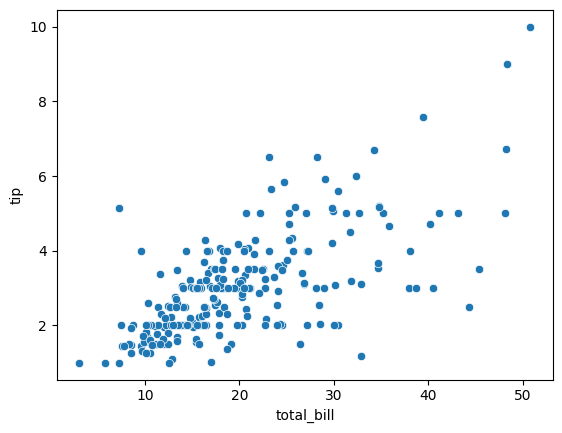

In [99]:
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.show()

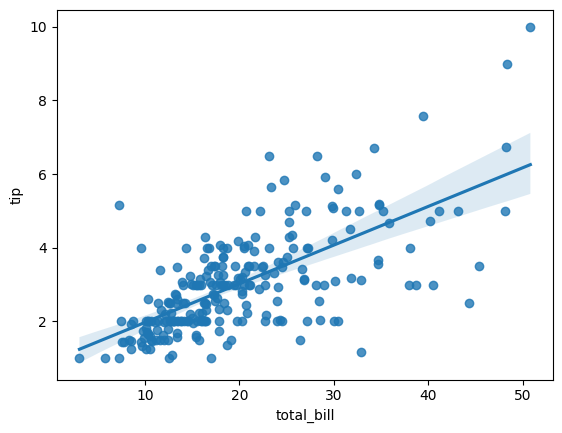

In [34]:
sns.regplot(data=df, x="total_bill", y="tip")
plt.show()

The scatter plot and regression line suggest a clear positive relationship between total bill and tip.
This supports the intuition that customers tend to leave larger tips when the bill is higher.

### 3.2 Tip Amount by Sex and Day

After confirming the relationship between bill and tip,
I explored whether tip amount differs across sex and day of the week.

In [8]:
df.groupby("sex")["tip"].mean()

/tmp/ipykernel_627/193511169.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")["tip"].mean()


,tip
sex,
Male,3.089618
Female,2.833448


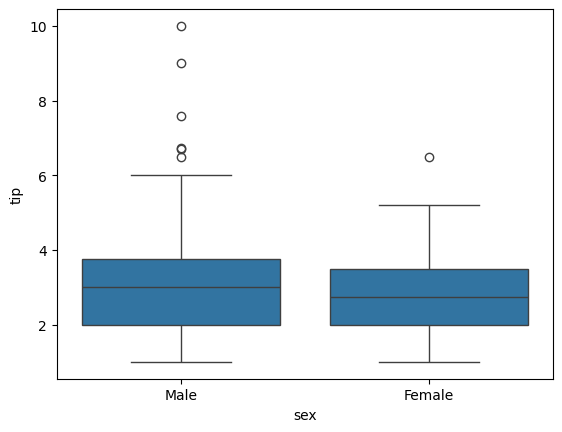

In [45]:
sns.boxplot(data=df, x="sex", y="tip")
plt.show()

In [10]:
df.groupby("day")["tip"].mean()

/tmp/ipykernel_627/2281761285.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("day")["tip"].mean()


,tip
day,
Thur,2.771452
Fri,2.734737
Sat,2.993103
Sun,3.255132


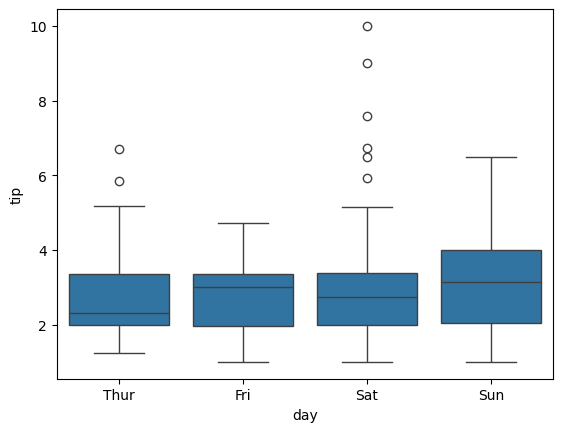

In [20]:
sns.boxplot(data=df, x="day", y="tip")
plt.show()

At this stage, tip amount appeared to differ by sex and by day.
However, I suspected that tip amount alone might be misleading because groups may differ in total bill size.
This led to the creation of a new variable: `tip_rate`.

### 3.3 Tip Rate

Since tip amount alone can be misleading when bill sizes differ across groups,
I created a derived variable:

`tip_rate = tip / total_bill`

This allowed fairer comparisons across categories.

In [115]:
df["tip_rate"] = df["tip"] / df["total_bill"]
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_rate
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808


### 3.3.1 Tip Rate By Day and Smoker

In [107]:
df.groupby("day")["tip_rate"].mean()

/tmp/ipykernel_627/2417942096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("day")["tip_rate"].mean()


,tip_rate
day,
Thur,0.161276
Fri,0.169913
Sat,0.153152
Sun,0.166897


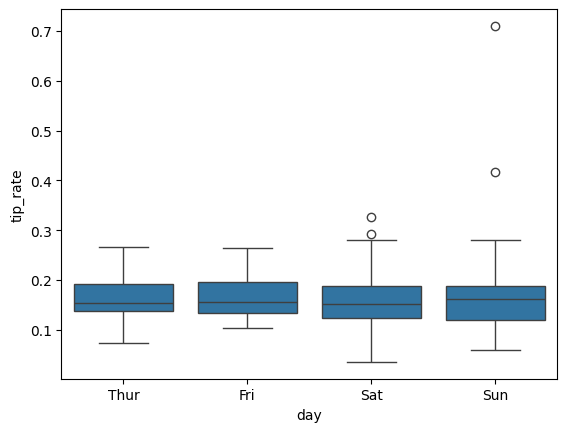

In [109]:
sns.boxplot(data=df, x="day", y="tip_rate")
plt.show()

In [18]:
df.groupby("smoker")["tip_rate"].mean()

/tmp/ipykernel_627/4229388349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("smoker")["tip_rate"].mean()


,tip_rate
smoker,
Yes,0.163196
No,0.159328


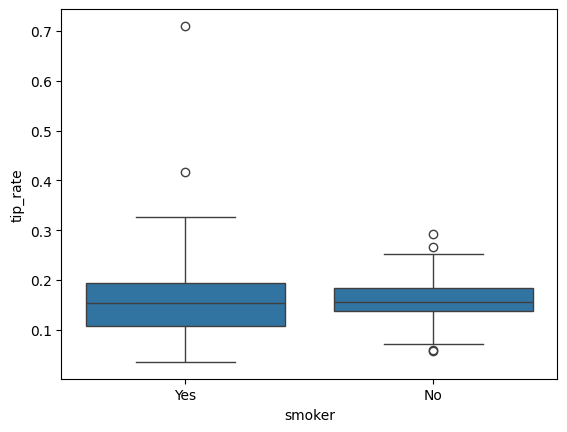

In [110]:
sns.boxplot(data=df, x="smoker", y="tip_rate")
plt.show()

Tip rate varies across days, with Friday showing relatively high values.
Smoker status alone does not appear to create a dramatic difference, but combined group analysis suggests more nuanced behavioral patterns.

### 3.3.2 Tip Rate by Sex and Combined Categories

In [111]:
df.groupby("sex")["tip_rate"].mean()

/tmp/ipykernel_627/3972007634.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")["tip_rate"].mean()


,tip_rate
sex,
Male,0.157651
Female,0.166491


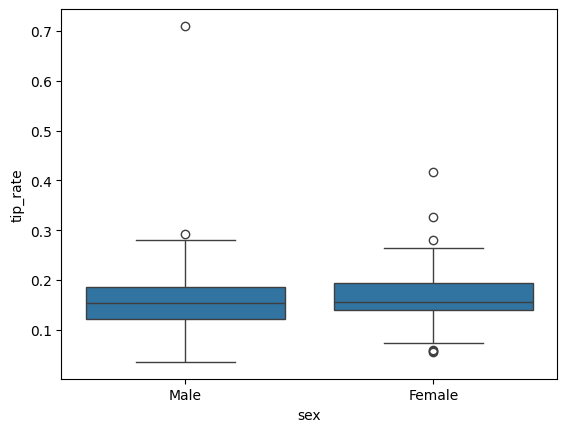

In [48]:
sns.boxplot(data=df, x="sex", y="tip_rate")
plt.show()

In [73]:
df.groupby(["smoker", "sex"])["tip_rate"].mean()

/tmp/ipykernel_627/767452404.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["smoker", "sex"])["tip_rate"].mean()


smoker  sex   
Yes     Male      0.152771
        Female    0.182150
No      Male      0.160669
        Female    0.156921
Name: tip_rate, dtype: float64

In [75]:
df.groupby(["day","time"])["tip_rate"].mean()

/tmp/ipykernel_627/4048635700.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["day","time"])["tip_rate"].mean()


day   time  
Thur  Lunch     0.161301
      Dinner    0.159744
Fri   Lunch     0.188765
      Dinner    0.158916
Sat   Lunch          NaN
      Dinner    0.153152
Sun   Lunch          NaN
      Dinner    0.166897
Name: tip_rate, dtype: float64

When I combined variables such as smoker status, sex, day, and time,
the patterns became more interesting.
This suggested that tipping behavior may reflect social context rather than a single variable alone.

### 3.4 Party Size

I then explored whether party size affects average tip, tip rate,
and the overall structure of the customer base.

In [27]:
df.groupby("size")["tip"].count()

,tip
size,
1,4
2,156
3,38
4,37
5,5
6,4


In [22]:
df.groupby("size")["tip"].mean()

,tip
size,
1,1.437500
2,2.582308
3,3.393158
4,4.135405
5,4.028000
6,5.225000


In [83]:
pd.pivot_table(
    df,
    values="tip_rate",
    index="size"
)

,tip_rate
size,
1,0.217292
2,0.165719
3,0.152157
4,0.145949
5,0.141495
6,0.156229


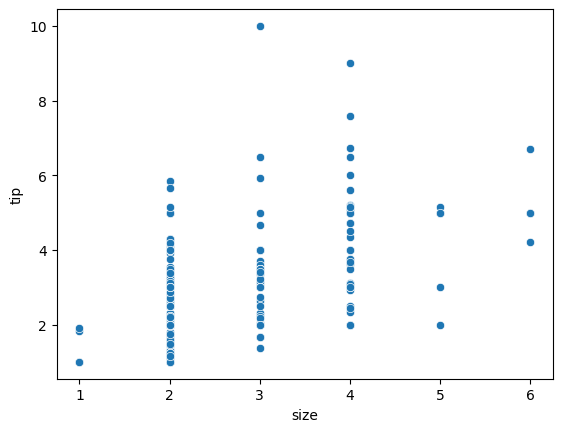

In [24]:
sns.scatterplot(data=df, x="size", y="tip")
plt.show()

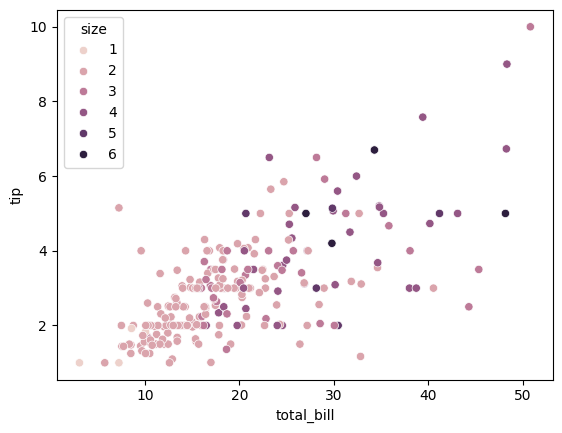

In [29]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="size")
plt.show()

Party size appeared to be related to tip behavior, but the number of observations drops sharply for larger groups.
This means any pattern for size 5 or 6 should be interpreted with caution.

### 3.5 Time of Day

I then examined whether lunch and dinner differ in bill size, tip amount,
and customer composition.
Dinner appeared more frequently in the dataset,
and dinner tables generally showed larger bills and tips than lunch tables.

In [78]:
pd.pivot_table(df,
               values="tip_rate",
               index="day",
               columns="time")

/tmp/ipykernel_627/4196540463.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,


time,Lunch,Dinner
day,,
Thur,0.161301,0.159744
Fri,0.188765,0.158916
Sat,NaN,0.153152
Sun,NaN,0.166897


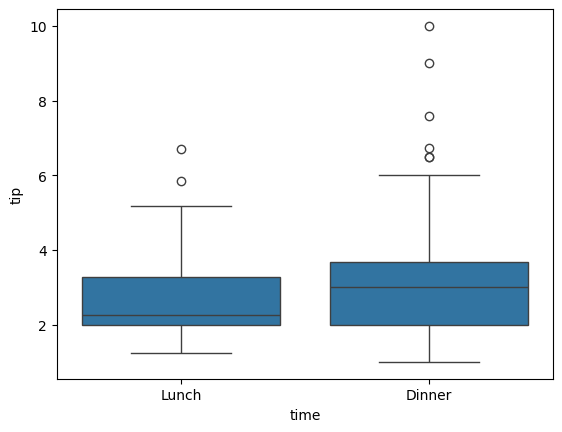

In [38]:
sns.boxplot(data=df, x="time", y="tip")
plt.show()

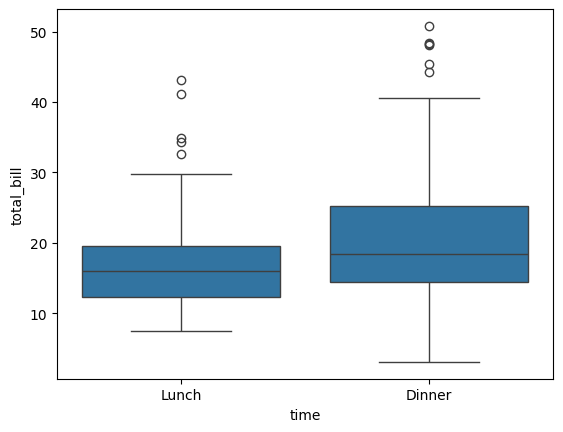

In [40]:
sns.boxplot(data=df, x="time", y="total_bill")
plt.show()

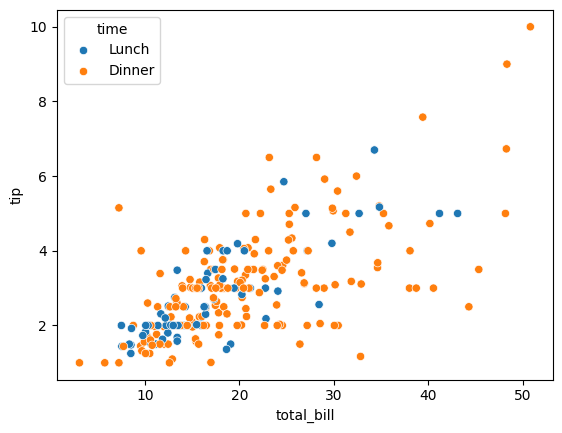

In [46]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time")
plt.show()

In [12]:
df.groupby("day")["total_bill"].mean()

/tmp/ipykernel_627/2472984912.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("day")["total_bill"].mean()


,total_bill
day,
Thur,17.682742
Fri,17.151579
Sat,20.441379
Sun,21.410000


In [94]:
pd.crosstab(df["size"], df["time"])

time,Lunch,Dinner
size,,
1,2,2
2,52,104
3,5,33
4,5,32
5,1,4
6,3,1


### 3.6 Payment Patterns by Sex

At this stage, I began to question the meaning of the variable `sex`.
Instead of interpreting it simply as customer gender,
I considered the possibility that it represents the sex of the bill payer.

This interpretation became more plausible when I examined the distribution of payer sex across time and party size.

In [81]:
pd.pivot_table(
    df,
    values="tip_rate",
    index="sex",
    columns="time"
)

/tmp/ipykernel_627/2549443655.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


time,Lunch,Dinner
sex,,
Male,0.166083,0.155407
Female,0.162285,0.169322


In [85]:
df[["total_bill","tip","size","tip_rate"]].corr()

,total_bill,tip,size,tip_rate
total_bill,1.000000,0.675734,0.598315,-0.338624
tip,0.675734,1.000000,0.489299,0.342370
size,0.598315,0.489299,1.000000,-0.142860
tip_rate,-0.338624,0.342370,-0.142860,1.000000


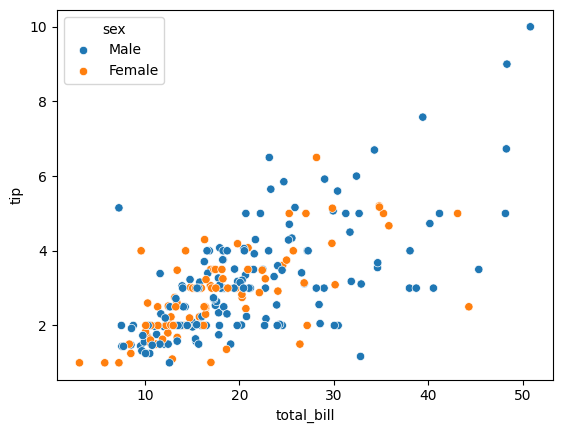

In [87]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex")
plt.show()

In [92]:
pd.crosstab(df["sex"], df["time"])

time,Lunch,Dinner
sex,,
Male,33,124
Female,35,52


In [96]:
pd.crosstab(df["sex"], df["size"])

size,1,2,3,4,5,6
sex,,,,,,
Male,1,98,24,28,4,2
Female,3,58,14,9,1,2


<Axes: xlabel='total_bill', ylabel='tip_rate'>

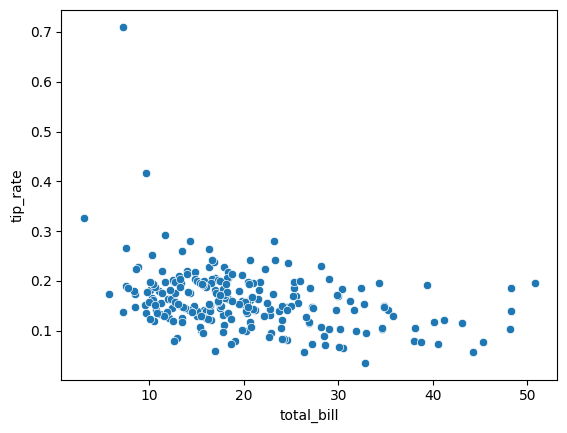

In [97]:
sns.scatterplot(data=df, x="total_bill", y="tip_rate")

Lunch showed relatively balanced male and female payer counts,
whereas dinner showed a much stronger dominance of male payers.
Combined with the high proportion of two-person tables,
this led to the hypothesis that dinner may include many couple-based visits
where the male partner more often pays the bill.

### 3.7 Smoker Status

I also explored whether smoker status is associated with differences
in total bill and tip behavior.
The results suggested that smoker status alone was not the strongest explanatory factor,
but it still contributed to some variation in group-level patterns.

In [65]:
df.groupby("smoker")["total_bill"].mean()

/tmp/ipykernel_627/2378905144.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("smoker")["total_bill"].mean()


,total_bill
smoker,
Yes,20.756344
No,19.188278


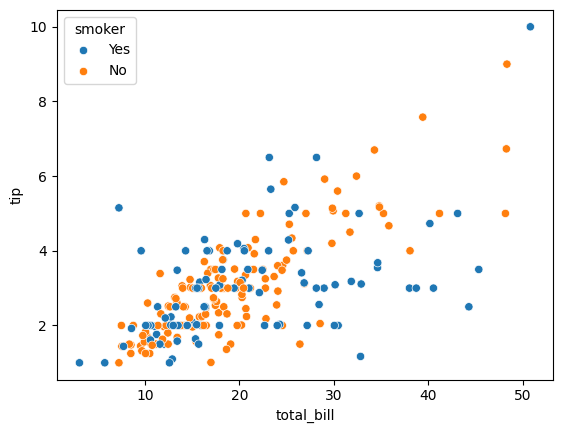

In [36]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="smoker")
plt.show()


## 4. Key Findings

Main findings from the exploratory analysis include:

- `total_bill` and `tip` show a clear positive relationship.
- Dinner appears much more frequently than lunch in the dataset.
- Two-person tables are by far the most common.
- Male payers appear more frequently than female payers overall.
- The difference between male and female payer counts becomes especially large at dinner.
- `tip_rate` is useful because tip amount alone can be misleading when bill size differs.
- Party size may be associated with lower `tip_rate`, but larger groups have fewer observations, so caution is needed.

These findings emerged through iterative visual exploration rather than from a single hypothesis alone.

## 5. Behavioral Interpretation

One of the most important interpretive shifts in this analysis
was reconsidering the meaning of the variable `sex`.

Rather than interpreting it simply as the gender of a customer at the table,
it seemed more reasonable to interpret it as the sex of the person who paid the bill.

This reinterpretation helped explain several patterns in the dataset:

- male payers appeared more frequently overall
- two-person tables dominated the dataset
- lunch showed relatively similar male and female payer counts
- dinner showed a much stronger dominance of male payers

Taken together, these patterns led to the hypothesis that the restaurant may receive many couple-based dinner visits,
and that in such cases the male partner may more often pay the bill.

I also considered that when group size increases,
male payers may bear greater financial responsibility because they are more frequently the bill payer.
This could help explain why male payers may show slightly lower tip rates
despite paying larger total bills.

## 6. Business Insights

The observed patterns suggest several practical business implications.

First, because dinner contains a much higher proportion of male payers
and two-person tables are especially common,
the restaurant may benefit from couple-oriented promotions.

Examples could include:

- anniversary events
- couple dinner promotions
- special celebration menus

These kinds of events may help increase both customer satisfaction and tip-related outcomes.

Second, from a business perspective, tip rate alone may not be the most meaningful metric.
Since tip amount tends to rise with total bill,
strategies that increase bill size may be more impactful overall.

Examples include:

- dessert recommendations
- premium menu suggestions
- drink or wine upselling
- event-based packages

Finally, if the actual goal is to improve restaurant performance,
it would be more useful to analyze total bill or tip amount per table turnover,
rather than focusing only on bill size per table.

## 7. Limitations & Further Data Needed

Although the dataset provides useful exploratory insights,
it is limited in scope and does not contain several variables
that would be necessary for stronger conclusions.

Additional variables that would improve the analysis include:

- server identity
- whether the diners were a couple
- menu categories ordered
- table duration / turnover time
- special events such as anniversaries or celebrations

These variables matter because the current dataset cannot fully explain
why customers tip the way they do.

For example:

- one server may consistently receive higher tips than others
- certain menu types may increase both bill size and tip amount
- table turnover time may matter more for actual revenue than bill size alone
- couple tables may behave differently from family or group tables

In other words, the current analysis is useful for generating behavioral hypotheses,
but more detailed operational and contextual data would be needed
to produce more accurate business conclusions.

## 8. Conclusion

This project began as a simple analysis of the relationship between total bill and tip,
but developed into a broader behavioral interpretation of restaurant payment patterns.

The dataset suggests that tipping behavior reflects not only bill size,
but also social context, payment roles, party size, and dinner-oriented customer patterns.

Most importantly, this project shows that exploratory data analysis
is not just about plotting graphs, but about interpreting variables,
forming hypotheses, and recognizing what additional data is needed.